In [ ]:
!pip install shap imbalanced-learn -q

import pandas as pd, numpy as np, shap, warnings
import matplotlib.pyplot as plt
import seaborn as sns # Added this line
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (roc_auc_score, f1_score, precision_score,
                             recall_score, confusion_matrix, classification_report)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from statsmodels.stats.contingency_tables import mcnemar
warnings.filterwarnings('ignore')

SEEDS = [42, 0, 123, 2024, 7]
print("numpy:", np.__version__, "| All imports OK")

numpy: 2.0.2 | All imports OK


In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

# Adjust this path to where your file actually sits in Drive.
# Example: if it's in "My Drive" root:
path = '/content/drive/MyDrive/model_ready_dataset_1.xlsx'

df = pd.read_excel(path)   # read_excel, not read_csv

# at_risk=0 means AT-RISK. Recode so positive class (1) = at-risk.
df['target'] = (df['at_risk'] == 0).astype(int)
print(df['target'].value_counts(), "\n1 = at-risk (positive class)")

Mounted at /content/drive
target
0    2760
1     565
Name: count, dtype: int64 
1 = at-risk (positive class)


In [ ]:
drop_cols = ['participant_id', 'at_risk', 'target']
cat_cols  = ['gender', 'programme', 'level', 'fee_payment_status']

X = pd.get_dummies(df.drop(columns=drop_cols), columns=cat_cols, drop_first=False)
y = df['target'].values
feature_names = X.columns.tolist()
print(f"{X.shape[1]} features after encoding")

43 features after encoding


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42)

scaler = MinMaxScaler()
X_train_s = scaler.fit_transform(X_train)     # fit on train only
X_test_s  = scaler.transform(X_test)

X_train_bal, y_train_bal = SMOTE(random_state=42).fit_resample(X_train_s, y_train)
print(f"Train after SMOTE: {np.bincount(y_train_bal)}  |  Test: {np.bincount(y_test)}")

Train after SMOTE: [2208 2208]  |  Test: [552 113]


### Data Visualization

Let's first visualize the distribution of our target variable ('at-risk' status) in the original dataset and compare it to the distribution in the SMOTE-balanced training set.

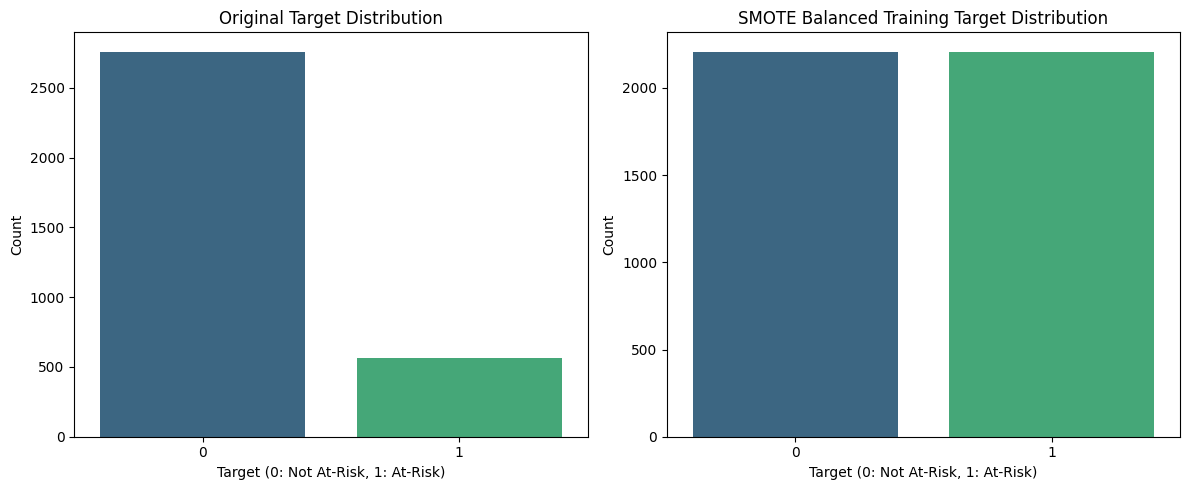

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x=y, ax=axes[0], palette='viridis')
axes[0].set_title('Original Target Distribution')
axes[0].set_xlabel('Target (0: Not At-Risk, 1: At-Risk)')
axes[0].set_ylabel('Count')

sns.countplot(x=y_train_bal, ax=axes[1], palette='viridis')
axes[1].set_title('SMOTE Balanced Training Target Distribution')
axes[1].set_xlabel('Target (0: Not At-Risk, 1: At-Risk)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

Next, let's look at the distributions of some key numerical features from the original dataset. We'll pick a few representative ones like total score, number of logins, and a few module scores to understand their spread.

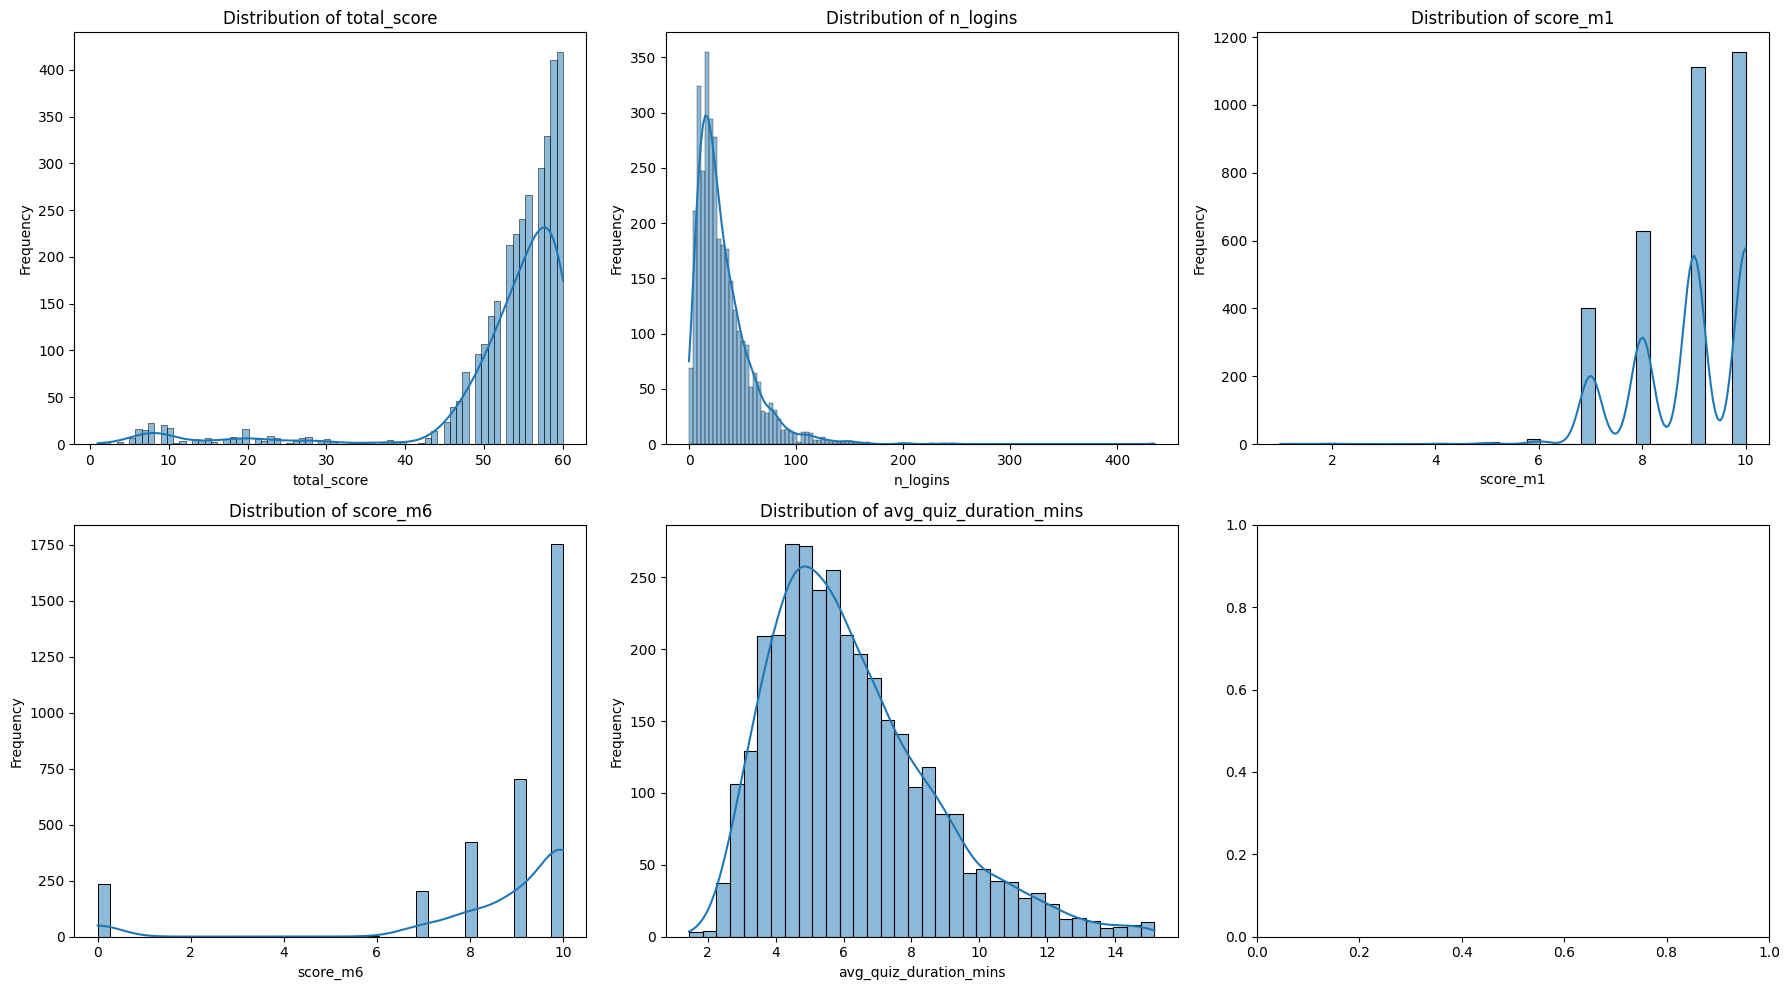

In [ ]:
numerical_features = ['total_score', 'n_logins', 'score_m1', 'score_m6', 'avg_quiz_duration_mins']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    if col in X.columns:
        sns.histplot(X[col], kde=True, ax=axes[i], palette='magma')
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')
    else:
        fig.delaxes(axes[i]) # Remove empty subplot if feature not found

plt.tight_layout()
plt.show()

Finally, let's explore how the original categorical features relate to our target variable (at-risk status). This will give us insights into which categories might be more prone to 'at-risk' students.

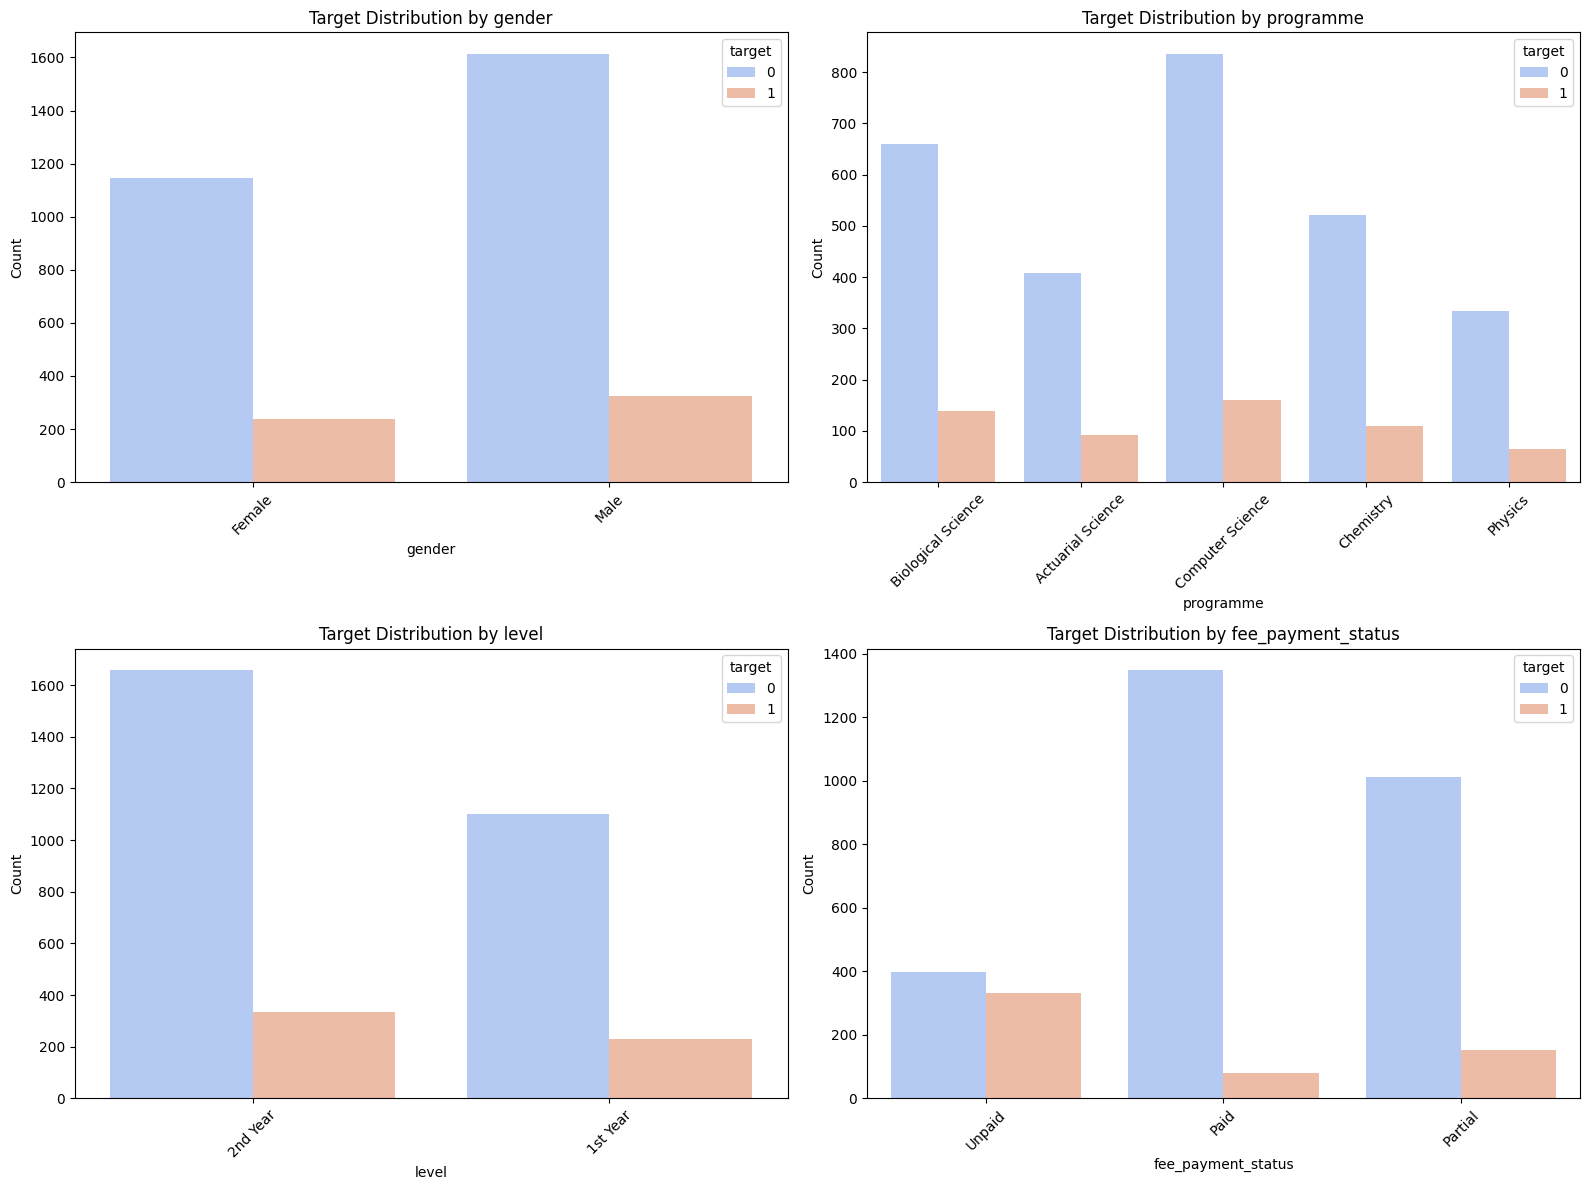

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    if col in df.columns:
        sns.countplot(x=col, hue='target', data=df, ax=axes[i], palette='coolwarm')
        axes[i].set_title(f'Target Distribution by {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')
        axes[i].tick_params(axis='x', rotation=45)
    else:
        fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [ ]:
param_grid = {
    'max_depth': [4, 6, 8],
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8],
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
gs = GridSearchCV(
    XGBClassifier(eval_metric='auc', random_state=42, use_label_encoder=False),
    param_grid, cv=cv, scoring='roc_auc', n_jobs=-1, verbose=1)
gs.fit(X_train_bal, y_train_bal)
best_params = gs.best_params_
print("Best params:", best_params, "| CV AUC:", round(gs.best_score_, 4))

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best params: {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 300, 'subsample': 0.8} | CV AUC: 0.9829


In [ ]:
def evaluate(model, Xte, yte):
    p  = model.predict(Xte)
    pp = model.predict_proba(Xte)[:, 1]
    return {'AUC': roc_auc_score(yte, pp), 'F1': f1_score(yte, p),
            'Precision': precision_score(yte, p), 'Recall': recall_score(yte, p)}

def run_seeds(ModelClass, kwargs, name):
    rows = []
    for s in SEEDS:
        Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.20,
                                              stratify=y, random_state=s)
        sc = MinMaxScaler(); Xtr_s = sc.fit_transform(Xtr); Xte_s = sc.transform(Xte)
        Xtr_b, ytr_b = SMOTE(random_state=s).fit_resample(Xtr_s, ytr)
        m = ModelClass(**kwargs); m.fit(Xtr_b, ytr_b)
        rows.append(evaluate(m, Xte_s, yte))
    r = pd.DataFrame(rows)
    print(f"\n{name}")
    for c in r.columns:
        print(f"  {c}: {r[c].mean():.3f} ± {r[c].std():.3f}")
    return r

xgb_res = run_seeds(XGBClassifier,
    {**best_params, 'eval_metric':'auc', 'use_label_encoder':False}, "XGBoost")


XGBoost
  AUC: 0.875 ± 0.009
  F1: 0.641 ± 0.020
  Precision: 0.765 ± 0.026
  Recall: 0.552 ± 0.025


In [ ]:
lr_res = run_seeds(LogisticRegression, {'max_iter':1000, 'C':1.0}, "Logistic Regression")
rf_res = run_seeds(RandomForestClassifier, {'n_estimators':100, 'random_state':42}, "Random Forest")

summary = pd.DataFrame({
    'XGBoost':   xgb_res.mean(), 'LogReg': lr_res.mean(), 'RandomForest': rf_res.mean()
}).T.round(3)
print("\n=== MODEL COMPARISON (mean over 5 seeds) ===")
print(summary)


Logistic Regression
  AUC: 0.893 ± 0.009
  F1: 0.620 ± 0.010
  Precision: 0.519 ± 0.017
  Recall: 0.772 ± 0.028

Random Forest
  AUC: 0.871 ± 0.012
  F1: 0.631 ± 0.023
  Precision: 0.765 ± 0.049
  Recall: 0.538 ± 0.028

=== MODEL COMPARISON (mean over 5 seeds) ===
                AUC     F1  Precision  Recall
XGBoost       0.875  0.641      0.765   0.552
LogReg        0.893  0.620      0.519   0.772
RandomForest  0.871  0.631      0.765   0.538


### Model Performance Comparison

Let's visualize the `summary` table to compare the performance metrics (AUC, F1, Precision, Recall) of the three models: XGBoost, Logistic Regression, and Random Forest.

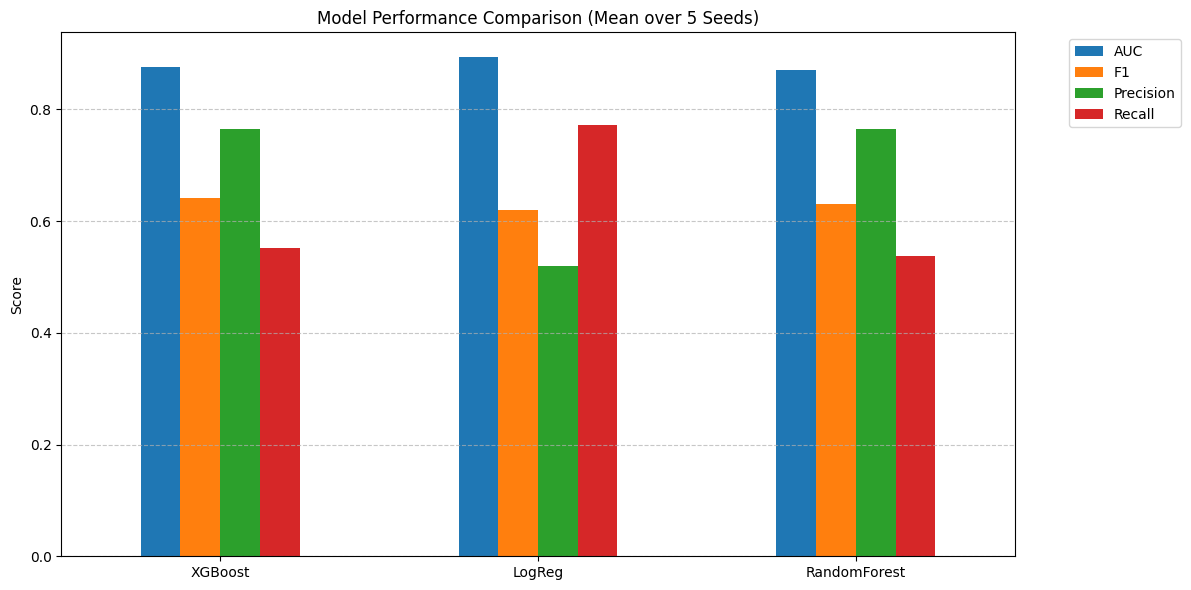

In [ ]:
summary.plot(kind='bar', figsize=(12, 6), rot=0)
plt.title('Model Performance Comparison (Mean over 5 Seeds)')
plt.ylabel('Score')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

This bar chart clearly shows how each model performs across different metrics. Logistic Regression, for example, has the highest AUC and Recall, while XGBoost and Random Forest have higher Precision and F1-score. This visual comparison helps in choosing a model based on the most critical evaluation metric for the problem at hand.

In [ ]:
# Single split for paired predictions
xgb = XGBClassifier(**best_params, eval_metric='auc', use_label_encoder=False).fit(X_train_bal, y_train_bal)
lr  = LogisticRegression(max_iter=1000).fit(X_train_bal, y_train_bal)
rf  = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train_bal, y_train_bal)

preds = {'XGB': xgb.predict(X_test_s), 'LR': lr.predict(X_test_s), 'RF': rf.predict(X_test_s)}
for name in ['LR', 'RF']:
    a = (preds['XGB'] == y_test); b = (preds[name] == y_test)
    table = [[np.sum(a & b), np.sum(a & ~b)],
             [np.sum(~a & b), np.sum(~a & ~b)]]
    res = mcnemar(table, exact=False, correction=True)
    sig = "significant" if res.pvalue < 0.017 else "NOT significant"
    print(f"XGB vs {name}: p = {res.pvalue:.4f}  ({sig} at α=0.017)")

XGB vs LR: p = 0.0006  (significant at α=0.017)
XGB vs RF: p = 0.4227  (NOT significant at α=0.017)


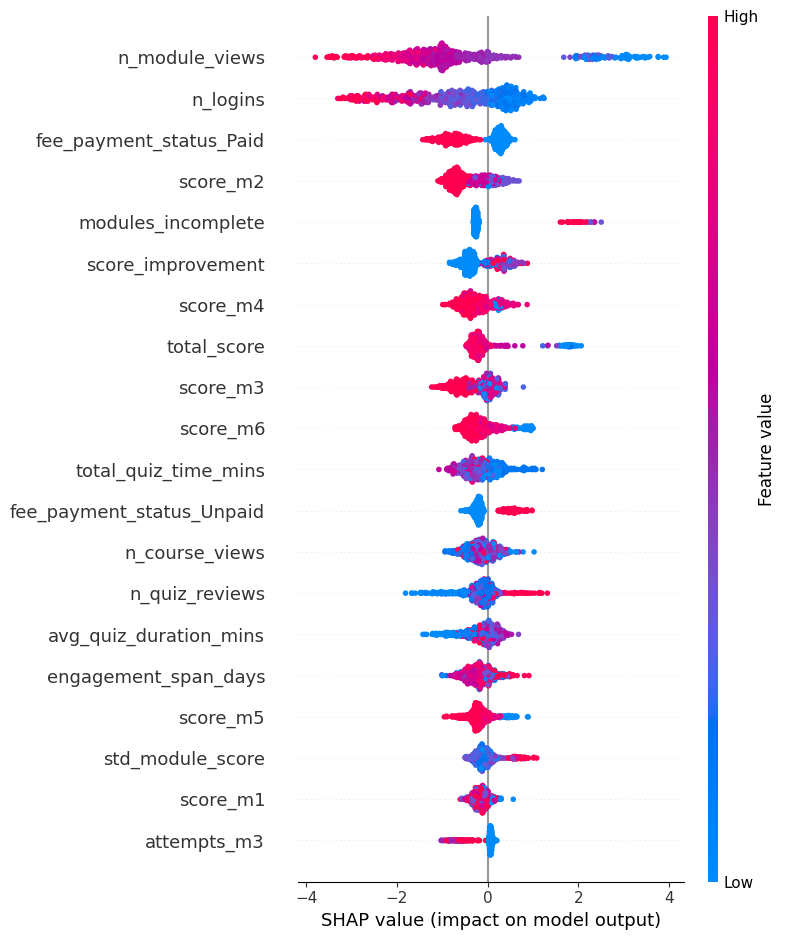

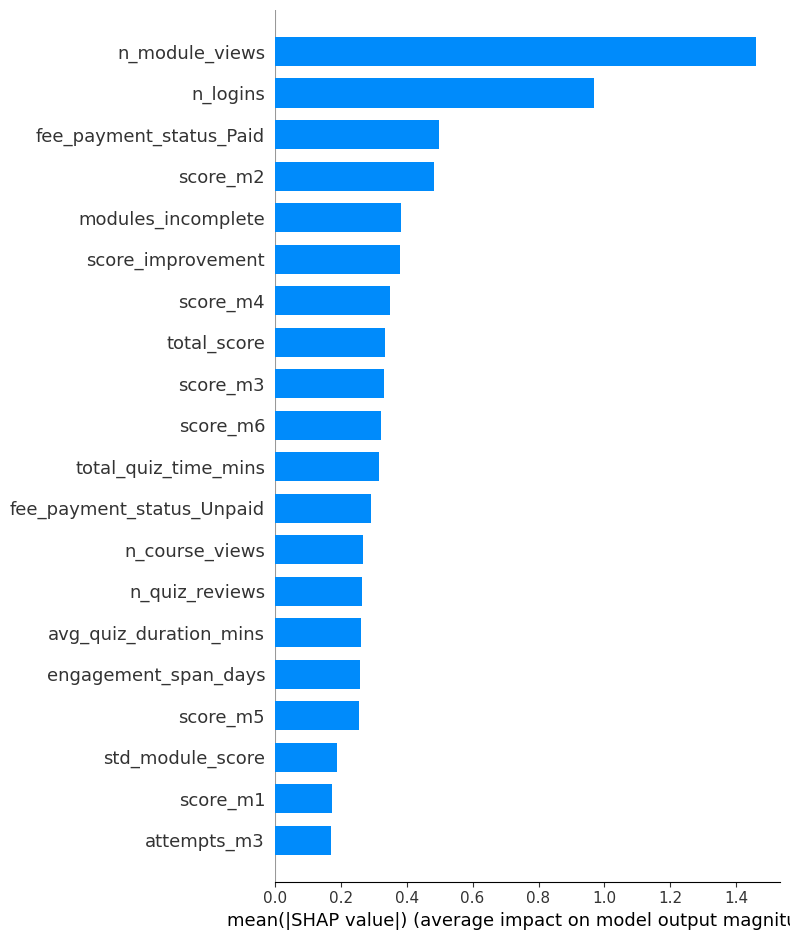

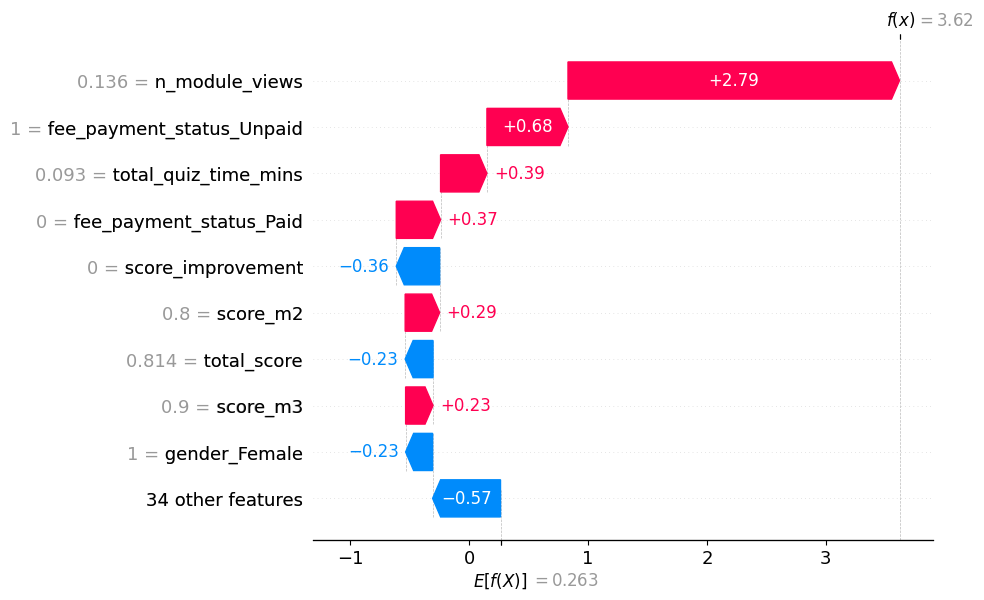

In [ ]:
explainer   = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test_s)

# Global beeswarm
shap.summary_plot(shap_values, X_test_s, feature_names=feature_names, show=True)

# Global bar (mean |SHAP|)
shap.summary_plot(shap_values, X_test_s, feature_names=feature_names,
                  plot_type='bar', show=True)

# Local waterfall for one at-risk student
at_risk_idx = np.where(y_test == 1)[0][0]
shap.plots.waterfall(
    shap.Explanation(values=shap_values[at_risk_idx],
                     base_values=explainer.expected_value,
                     data=X_test_s[at_risk_idx],
                     feature_names=feature_names), show=True)

In [ ]:
def fairness(y_true, y_pred, groups):
    out = {}
    for g in np.unique(groups):
        m = groups == g
        if m.sum() < 30:   # skip tiny subgroups
            continue
        tn, fp, fn, tp = confusion_matrix(y_true[m], y_pred[m], labels=[0,1]).ravel()
        tpr = tp / (tp + fn) if (tp+fn) else 0       # recall on at-risk
        fpr = fp / (fp + tn) if (fp+tn) else 0
        out[g] = {'n': int(m.sum()), 'TPR': round(tpr,3), 'FPR': round(fpr,3)}
    return pd.DataFrame(out).T

# Align demographic columns to the test split
test_idx = X_test.index
for attr in ['gender', 'programme', 'level', 'fee_payment_status']:
    grp = df.loc[test_idx, attr].values
    print(f"\n=== Fairness by {attr} ===")
    fr = fairness(y_test, xgb.predict(X_test_s), grp)
    print(fr)
    if len(fr) > 1:
        print(f"  Equal Opportunity Diff (max TPR gap): {fr['TPR'].max()-fr['TPR'].min():.3f}")
        print(f"  Equalized Odds Diff   (max FPR gap): {fr['FPR'].max()-fr['FPR'].min():.3f}")


=== Fairness by gender ===
            n    TPR    FPR
Female  289.0  0.467  0.025
Male    376.0  0.559  0.036
  Equal Opportunity Diff (max TPR gap): 0.092
  Equalized Odds Diff   (max FPR gap): 0.011

=== Fairness by programme ===
                        n    TPR    FPR
Actuarial Science   105.0  0.500  0.022
Biological Science  148.0  0.481  0.025
Chemistry           141.0  0.500  0.018
Computer Science    193.0  0.643  0.048
Physics              78.0  0.429  0.031
  Equal Opportunity Diff (max TPR gap): 0.214
  Equalized Odds Diff   (max FPR gap): 0.030

=== Fairness by level ===
              n    TPR    FPR
1st Year  257.0  0.600  0.024
2nd Year  408.0  0.471  0.035
  Equal Opportunity Diff (max TPR gap): 0.129
  Equalized Odds Diff   (max FPR gap): 0.011

=== Fairness by fee_payment_status ===
             n    TPR    FPR
Paid     295.0  0.158  0.014
Partial  224.0  0.259  0.020
Unpaid   146.0  0.731  0.114
  Equal Opportunity Diff (max TPR gap): 0.573
  Equalized Odds Diff   (

### Fairness Metrics Visualization

Now, let's visualize the fairness metrics calculated for the XGBoost model across different demographic groups. We will plot the True Positive Rate (TPR) and False Positive Rate (FPR) for each group within `gender`, `programme`, `level`, and `fee_payment_status`.

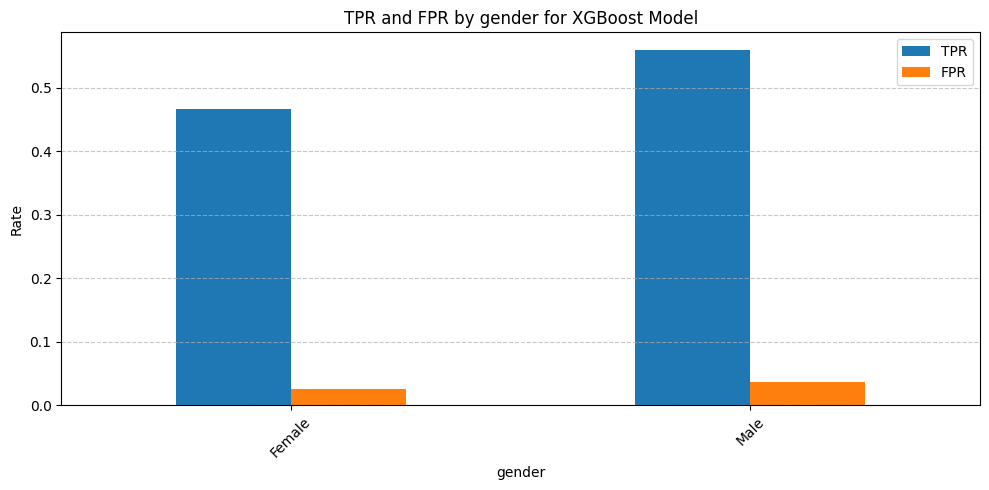

Equal Opportunity Diff (max TPR gap) for gender: 0.092
Equalized Odds Diff (max FPR gap) for gender: 0.011

---



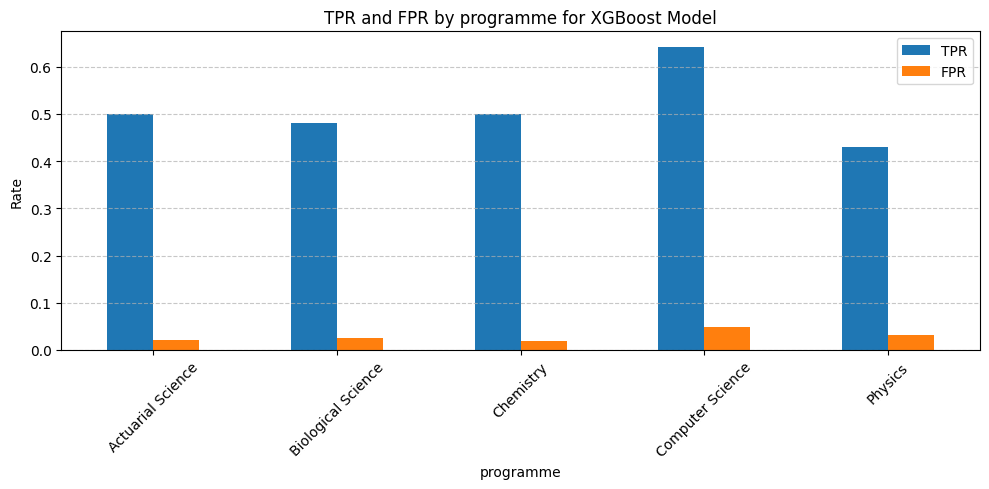

Equal Opportunity Diff (max TPR gap) for programme: 0.214
Equalized Odds Diff (max FPR gap) for programme: 0.030

---



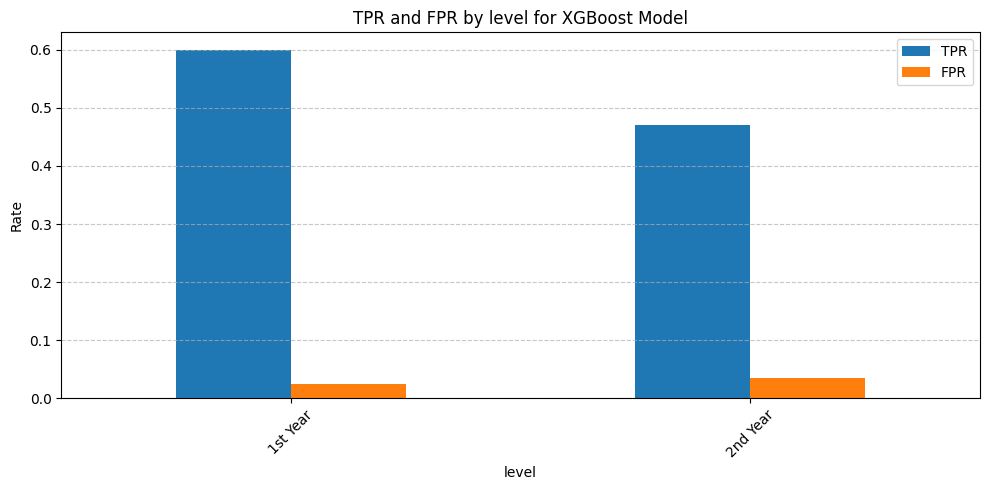

Equal Opportunity Diff (max TPR gap) for level: 0.129
Equalized Odds Diff (max FPR gap) for level: 0.011

---



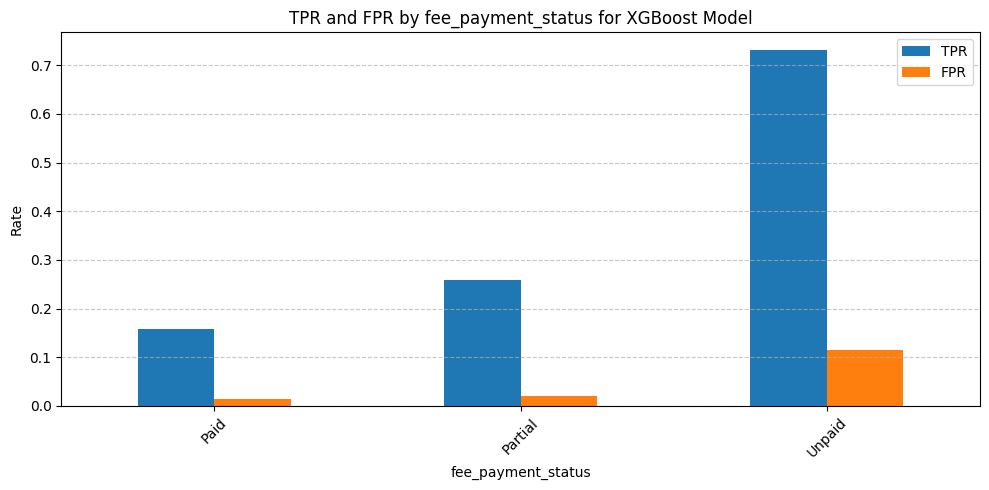

Equal Opportunity Diff (max TPR gap) for fee_payment_status: 0.573
Equalized Odds Diff (max FPR gap) for fee_payment_status: 0.100

---



In [ ]:
for attr in ['gender', 'programme', 'level', 'fee_payment_status']:
    grp = df.loc[X_test.index, attr].values
    fr = fairness(y_test, xgb.predict(X_test_s), grp)

    if len(fr) > 1:
        fr_plot = fr[['TPR', 'FPR']].plot(kind='bar', figsize=(10, 5), rot=45)
        plt.title(f'TPR and FPR by {attr} for XGBoost Model')
        plt.ylabel('Rate')
        plt.xlabel(attr)
        plt.legend(loc='upper right')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

        print(f"Equal Opportunity Diff (max TPR gap) for {attr}: {fr['TPR'].max()-fr['TPR'].min():.3f}")
        print(f"Equalized Odds Diff (max FPR gap) for {attr}: {fr['FPR'].max()-fr['FPR'].min():.3f}")
        print('\n---\n') # Separator

These plots illustrate the fairness of the XGBoost model across different demographic groups. For each attribute, you can see the True Positive Rate (how well the model identifies at-risk students) and False Positive Rate (how often the model incorrectly identifies non-at-risk students as at-risk) for various subgroups. The 'Equal Opportunity Diff' highlights the largest difference in TPR among groups, indicating disparities in correctly identifying the positive class. The 'Equalized Odds Diff' shows the largest difference in FPR, pointing to disparities in false alarms. These visualizations are crucial for identifying and addressing potential biases in the model's predictions.

In [ ]:
import joblib

joblib.dump({
    'model': xgb,
    'scaler': scaler,
    'feature_names': feature_names
}, '/content/drive/MyDrive/atrisk_bundle.pkl')
print("Model + scaler + features saved as a bundle.")

Model + scaler + features saved as a bundle.


# New section

In [ ]:
import numpy as np
import pandas as pd
import joblib
import json
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import roc_auc_score, roc_curve, f1_score, precision_score, recall_score
from scipy.stats import chi2


In [ ]:
DATA_PATH   = "model_ready_dataset_1.xlsx"      # the REAL 3,325-row dataset
OLD_BUNDLE  = "cinque_model_bundle.joblib"      # optional: reuse its hyperparams; set None to use HPARAMS below
OUT_PREFIX  = "cinque_v2"

SEEDS          = [42, 123, 456, 789, 1010]      # multi-seed hold-out evaluation
RETAIN         = 0.95                            # cumulative |SHAP| retention for pruning
TARGET_RECALL  = 0.75                            # screening-threshold target (recorded protocol)
RUN_REPEATED_CV = True                           # also run 5x5 repeated stratified CV (CAN-DO Step 3)

HPARAMS = dict(                                  # used only if OLD_BUNDLE is None
    n_estimators=300, max_depth=4, learning_rate=0.08,
    subsample=0.9, colsample_bytree=0.9,
    eval_metric="auc", n_jobs=-1,
)

CATS = {
    "gender": ["Female", "Male"],
    "programme": ["Actuarial Science", "Biological Science", "Chemistry", "Computer Science", "Physics"],
    "level": ["1st Year", "2nd Year"],
    "fee_payment_status": ["Paid", "Partial", "Unpaid"],
}

In [ ]:
import os

# Update paths to point to Google Drive where the files were previously used
DATA_PATH   = "/content/drive/MyDrive/model_ready_dataset_1.xlsx"
OLD_BUNDLE  = "/content/drive/MyDrive/atrisk_bundle.pkl"  # Updated to match the bundle saved in cell 4GoOlXtIJrFS
OUT_PREFIX  = "cinque_v2"

# 1. LOAD + SANITY GATES
# ----------------------------------------------------------------------------
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Could not find {DATA_PATH}. Please ensure Drive is mounted correctly.")

df = pd.read_excel(DATA_PATH)
assert df.shape[0] == 3325, f"WRONG DATASET: expected 3,325 rows, got {df.shape[0]}"
y = (df["at_risk"] == 0).astype(int)             # encoding is inverted: at_risk==0 IS the at-risk minority
assert y.sum() == 565, f"WRONG LABELS: expected 565 at-risk, got {y.sum()}"
print(f"[ok] dataset {df.shape}, at-risk = {y.sum()} ({y.mean():.1%})")

drop_cols = ["participant_id", "at_risk"]
raw = df.drop(columns=[c for c in drop_cols if c in df.columns])
for c, cats in CATS.items():
    raw[c] = pd.Categorical(raw[c], categories=cats)
X = pd.get_dummies(raw, columns=list(CATS))
assert X.shape[1] == 43, f"expected 43 encoded features, got {X.shape[1]}"
print(f"[ok] encoded feature matrix: {X.shape}")

if OLD_BUNDLE and os.path.exists(OLD_BUNDLE):
    _old = joblib.load(OLD_BUNDLE)
    # Check if the bundle is a dictionary or the model itself
    if isinstance(_old, dict) and 'model' in _old:
        params = _old["model"].get_params()
    else:
        params = _old.get_params()
    params.pop("missing", None)
    print("[ok] hyperparameters cloned from existing bundle")
else:
    print("[info] OLD_BUNDLE not found or not specified, using HPARAMS")
    params = HPARAMS

FEE_COLS = [c for c in X.columns if c.startswith("fee_payment_status_")]

[ok] dataset (3325, 37), at-risk = 565 (17.0%)
[ok] encoded feature matrix: (3325, 43)
[ok] hyperparameters cloned from existing bundle


In [ ]:
# 2. SHAP-GUIDED PRUNING (defined on the seed-42 training fold, as recorded)
# ----------------------------------------------------------------------------
Xtr0, Xte0, ytr0, yte0 = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

base = XGBClassifier(**params).fit(Xtr0, ytr0)
booster = base.get_booster()
dm = xgb.DMatrix(Xtr0, feature_names=list(X.columns))
contribs = booster.predict(dm, pred_contribs=True)[:, :-1]           # drop bias column
mean_abs = pd.Series(np.abs(contribs).mean(axis=0), index=X.columns).sort_values(ascending=False)

cum = mean_abs.cumsum() / mean_abs.sum()
pruned_cols = list(cum[cum <= RETAIN].index)
if len(pruned_cols) < len(cum):                                      # include the feature that crosses the line
    pruned_cols.append(cum.index[len(pruned_cols)])
print(f"[ok] pruning at {RETAIN:.0%} cumulative |SHAP|: 43 -> {len(pruned_cols)} features")

deployed_cols = [c for c in pruned_cols if c not in FEE_COLS]         # fairness screen
print(f"[ok] fairness screen (drop fee status): {len(pruned_cols)} -> {len(deployed_cols)} features")

CONFIGS = {"full_43": list(X.columns), "pruned": pruned_cols, "deployed": deployed_cols}

[ok] pruning at 95% cumulative |SHAP|: 43 -> 26 features
[ok] fairness screen (drop fee status): 26 -> 23 features


In [ ]:
 #3. MULTI-SEED EVALUATION — the numbers of record
# ----------------------------------------------------------------------------
def evaluate(cols, Xtr, Xte, ytr, yte):
    m = XGBClassifier(**params).fit(Xtr[cols], ytr)
    p = m.predict_proba(Xte[cols])[:, 1]
    yhat = (p >= 0.5).astype(int)
    return m, p, dict(
        auc=roc_auc_score(yte, p),
        macro_f1=f1_score(yte, yhat, average="macro"),
        precision=precision_score(yte, yhat, zero_division=0),
        recall=recall_score(yte, yhat),
    )

rows, seed42_probs, seed42_models = [], {}, {}
for seed in SEEDS:
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.20, stratify=y, random_state=seed)
    for name, cols in CONFIGS.items():
        m, p, met = evaluate(cols, Xtr, Xte, ytr, yte)
        rows.append(dict(seed=seed, config=name, **met))
        if seed == 42:
            seed42_probs[name], seed42_models[name] = p, m
    if seed == 42:
        Xte42, yte42, Xtr42, ytr42 = Xte, yte, Xtr, ytr

res = pd.DataFrame(rows)
summary = res.drop(columns=["seed"]).groupby("config").agg(["mean", "std"]).round(4)
print("\n===== MULTI-SEED SUMMARY (mean / std over", len(SEEDS), "seeds) =====")
print(summary.to_string())
res.to_csv(f"{OUT_PREFIX}_metrics_per_seed.csv", index=False)
summary.to_csv(f"{OUT_PREFIX}_metrics_summary.csv")



===== MULTI-SEED SUMMARY (mean / std over 5 seeds) =====
             auc         macro_f1         precision          recall        
            mean     std     mean     std      mean     std    mean     std
config                                                                     
deployed  0.8598  0.0145   0.7800  0.0110    0.8157  0.0553  0.5027  0.0289
full_43   0.8604  0.0170   0.7755  0.0160    0.7780  0.0536  0.5097  0.0399
pruned    0.8658  0.0178   0.7773  0.0133    0.8074  0.0799  0.5009  0.0231


In [ ]:
# 4. McNEMAR EQUIVALENCE (full vs pruned, seed-42 test set) — with chi^2 this time
# ----------------------------------------------------------------------------
yh_full   = (seed42_probs["full_43"] >= 0.5).astype(int)
yh_pruned = (seed42_probs["pruned"]  >= 0.5).astype(int)
b = int(((yh_full == yte42.values) & (yh_pruned != yte42.values)).sum())
c = int(((yh_full != yte42.values) & (yh_pruned == yte42.values)).sum())
chi2_stat = (abs(b - c) - 1) ** 2 / (b + c) if (b + c) > 0 else 0.0   # continuity-corrected
p_mcnemar = float(chi2.sf(chi2_stat, df=1)) if (b + c) > 0 else 1.0
print(f"\n[McNemar] discordant pairs b={b}, c={c}, chi2={chi2_stat:.3f}, p={p_mcnemar:.3f}")



[McNemar] discordant pairs b=3, c=9, chi2=2.083, p=0.149


In [ ]:
# 5. FAIRNESS: equal-opportunity gap by fee status (deployed vs pruned)
# ----------------------------------------------------------------------------
fee_raw = df.loc[Xte42.index, "fee_payment_status"]
def eo_gap(probs, thresh=0.5):
    yhat = (probs >= thresh).astype(int)
    rec = {}
    for g in CATS["fee_payment_status"]:
        mask = (fee_raw.values == g) & (yte42.values == 1)
        if mask.sum() > 0:
            rec[g] = yhat[mask].mean()
    return rec, (max(rec.values()) - min(rec.values()))
rec_pruned, gap_pruned = eo_gap(seed42_probs["pruned"])
rec_dep, gap_dep = eo_gap(seed42_probs["deployed"])
print(f"[fairness] EO recall by fee status — pruned: { {k: round(v,3) for k,v in rec_pruned.items()} } gap={gap_pruned:.2f}")
print(f"[fairness] EO recall by fee status — deployed: { {k: round(v,3) for k,v in rec_dep.items()} } gap={gap_dep:.2f}")


[fairness] EO recall by fee status — pruned: {'Paid': np.float64(0.211), 'Partial': np.float64(0.222), 'Unpaid': np.float64(0.701)} gap=0.49
[fairness] EO recall by fee status — deployed: {'Paid': np.float64(0.316), 'Partial': np.float64(0.296), 'Unpaid': np.float64(0.701)} gap=0.41


In [ ]:
# 6. SCREENING THRESHOLD for the deployed model (target recall on validation)
# ----------------------------------------------------------------------------
Xtr_in, Xval, ytr_in, yval = train_test_split(Xtr42, ytr42, test_size=0.25, stratify=ytr42, random_state=42)
m_thresh = XGBClassifier(**params).fit(Xtr_in[deployed_cols], ytr_in)
pv = m_thresh.predict_proba(Xval[deployed_cols])[:, 1]
ths = np.unique(pv)
ok = [t for t in ths if recall_score(yval, (pv >= t).astype(int)) >= TARGET_RECALL]
threshold = float(max(ok)) if ok else 0.5
p_dep_te = seed42_probs["deployed"]
rec_at = recall_score(yte42, (p_dep_te >= threshold).astype(int))
prec_at = precision_score(yte42, (p_dep_te >= threshold).astype(int), zero_division=0)
print(f"[threshold] {threshold:.4f} -> test recall {rec_at:.3f}, precision {prec_at:.3f}")


[threshold] 0.0442 -> test recall 0.717, precision 0.458


In [ ]:
# 7. OPTIONAL: repeated stratified CV (CAN-DO Step 3 — variance done properly)
# ----------------------------------------------------------------------------
if RUN_REPEATED_CV:
    rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)
    cvrows = []
    for fold, (tr, te) in enumerate(rskf.split(X, y)):
        for name, cols in CONFIGS.items():
            m = XGBClassifier(**params).fit(X.iloc[tr][cols], y.iloc[tr])
            p = m.predict_proba(X.iloc[te][cols])[:, 1]
            cvrows.append(dict(fold=fold, config=name, auc=roc_auc_score(y.iloc[te], p)))
    cv = pd.DataFrame(cvrows)
    print("\n===== REPEATED 5x5 STRATIFIED CV (AUC mean / std over 25 folds) =====")
    print(cv.groupby("config")["auc"].agg(["mean", "std"]).round(4).to_string())
    cv.to_csv(f"{OUT_PREFIX}_repeated_cv.csv", index=False)


===== REPEATED 5x5 STRATIFIED CV (AUC mean / std over 25 folds) =====
            mean     std
config                  
deployed  0.8590  0.0170
full_43   0.8645  0.0157
pruned    0.8677  0.0146


In [ ]:
# 8. FIGURES — ROC (Figure 4) and SHAP summary (Figure 5), from THESE runs
# ----------------------------------------------------------------------------
plt.rcParams.update({"font.family": "serif", "font.size": 10, "figure.dpi": 300})
fig, ax = plt.subplots(figsize=(5.4, 4.4))
styles = {"full_43": ("--", "#5b7d99", "Full, 43 features"),
          "pruned":  ("-.", "#3d7a4f", f"Pruned, {len(pruned_cols)} features"),
          "deployed": ("-", "#1c4a2c", f"Deployed, {len(deployed_cols)} features")}
for name, (ls, ccol, lab) in styles.items():
    fpr, tpr, _ = roc_curve(yte42, seed42_probs[name])
    auc = roc_auc_score(yte42, seed42_probs[name])
    ax.plot(fpr, tpr, ls, color=ccol, lw=1.8, label=f"{lab} (AUC = {auc:.3f})")
ax.plot([0, 1], [0, 1], ":", color="#999", lw=1, label="Chance")
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
ax.legend(loc="lower right", fontsize=8, frameon=True)
ax.spines[["top", "right"]].set_visible(False)
fig.savefig(f"{OUT_PREFIX}_FIG4_roc.png", bbox_inches="tight", dpi=300); plt.close()

dm_dep = xgb.DMatrix(Xte42[deployed_cols], feature_names=deployed_cols)
sc_dep = seed42_models["deployed"].get_booster().predict(dm_dep, pred_contribs=True)[:, :-1]
sv = pd.Series(np.abs(sc_dep).mean(axis=0), index=deployed_cols).sort_values(ascending=False)
top = sv.head(10)[::-1]
fig, ax = plt.subplots(figsize=(6.2, 3.8))
ax.barh(top.index, top.values, color="#5b7d99")
for i, v in enumerate(top.values):
    ax.text(v + 0.02, i, f"{v:.2f}", va="center", fontsize=8.5)
ax.set_xlabel("Mean |SHAP value| (impact on model output)")
ax.spines[["top", "right"]].set_visible(False)
fig.savefig(f"{OUT_PREFIX}_FIG5_shap.png", bbox_inches="tight", dpi=300); plt.close()
sv.to_csv(f"{OUT_PREFIX}_shap_values.csv")
print(f"\n[figures] {OUT_PREFIX}_FIG4_roc.png, {OUT_PREFIX}_FIG5_shap.png written")



[figures] cinque_v2_FIG4_roc.png, cinque_v2_FIG5_shap.png written


### Pruning Experiment Results

Below are the visualizations and the summary statistics from the multi-seed evaluation. These figures illustrate the trade-off between model complexity and performance, as well as the impact of the fairness screen.

Figure 4: ROC Curve Comparison


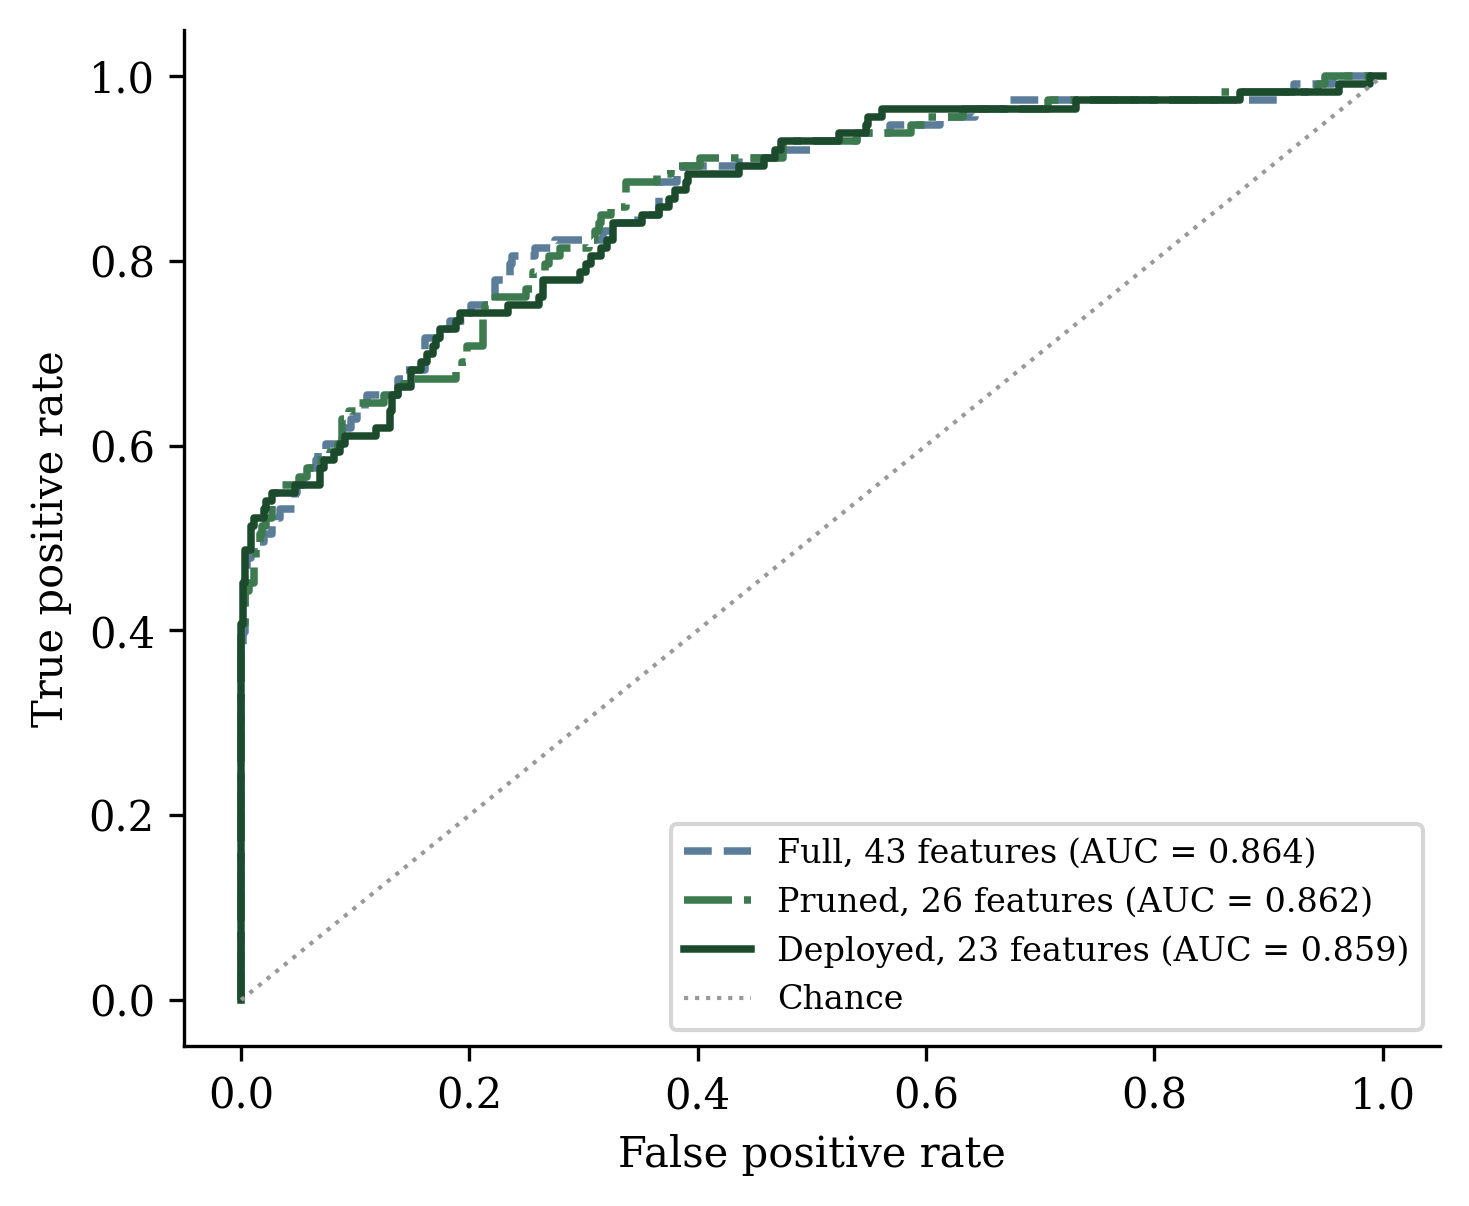


Figure 5: SHAP Feature Importance (Deployed Model)


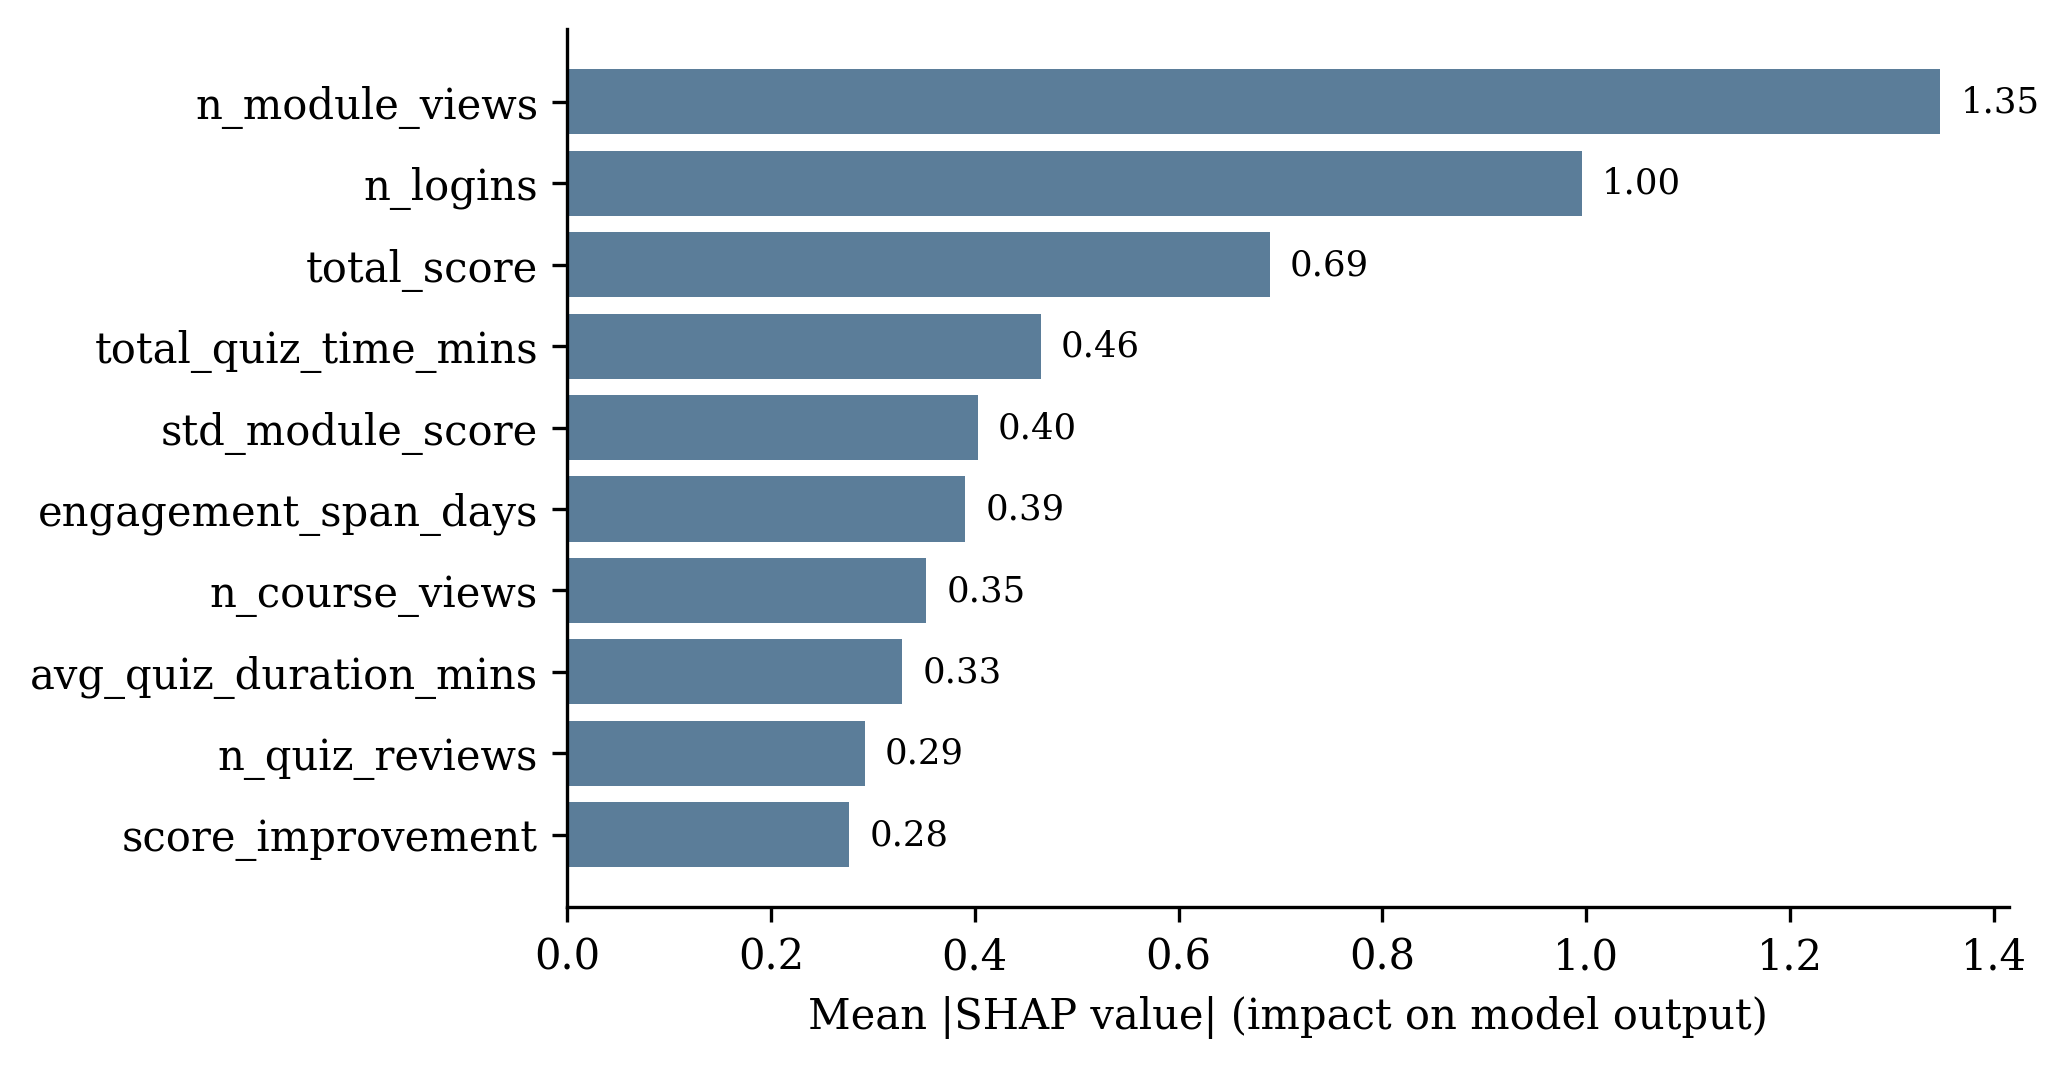

In [ ]:
import IPython.display
from IPython.display import Image, display

# Display the ROC Curve Comparison (Figure 4)
print("Figure 4: ROC Curve Comparison")
display(Image(filename=f"{OUT_PREFIX}_FIG4_roc.png"))

# Display the SHAP Importance for Deployed Features (Figure 5)
print("\nFigure 5: SHAP Feature Importance (Deployed Model)")
display(Image(filename=f"{OUT_PREFIX}_FIG5_shap.png"))

#### Performance Summary
This table shows the mean and standard deviation of key metrics (AUC, F1, Precision, Recall) across all evaluation seeds.

In [ ]:
# Display the summary table stored in the 'summary' variable
display(summary)

auc         macro_f1         precision          recall        
            mean     std     mean     std      mean     std    mean     std
config                                                                     
deployed  0.8598  0.0145   0.7800  0.0110    0.8157  0.0553  0.5027  0.0289
full_43   0.8604  0.0170   0.7755  0.0160    0.7780  0.0536  0.5097  0.0399
pruned    0.8658  0.0178   0.7773  0.0133    0.8074  0.0799  0.5009  0.0231

In [1]:
!python --version

Python 3.12.13
